Part 1 : Matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
titanic = sns.load_dataset("titanic")

In [4]:
titanic.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

In [5]:
age_filled = titanic["age"].fillna(titanic["age"].mean())
titanic["age_filled"] = age_filled
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic["embark_town"] = titanic["embark_town"].fillna(titanic["embark_town"].mode()[0])

هون نضفنا البيانات بحيث عوضنا المفقود من العمر بمتوسط الاعمار
و المفقود من ميناء الصعود بالقيمة الاكثر تكرارا

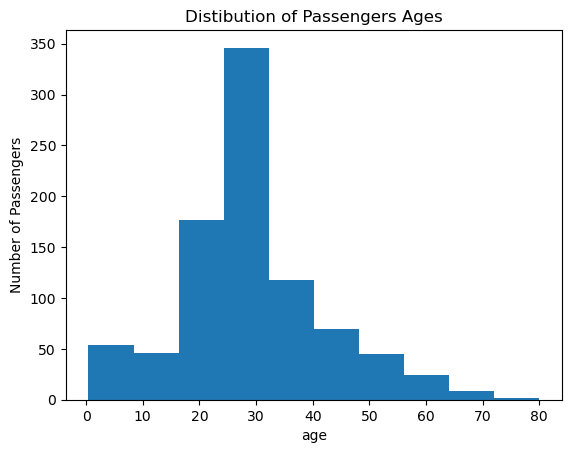

In [6]:
#ارسم Histogram لعمود age — شو شكل توزيع الأعمار؟ (متمركز حوالين رقم معين؟ متفرّق؟).
plt.hist(titanic['age_filled'])
plt.title("Distibution of Passengers Ages")
plt.ylabel("Number of Passengers")
plt.xlabel("age")
plt.show()

يوضح الرسم البياني Histogram ان توزيع اعمار الركاب تتوزع حول ال 30 بكثرة 
الفئة بين 20 و 40 عام تضم اعلى عدد من الركاب
فئة كبار السن و صغار السن تضم اقل عدد من الركاب تقريبا
بالتالي فإن غالية الركاب هم من الشباب 

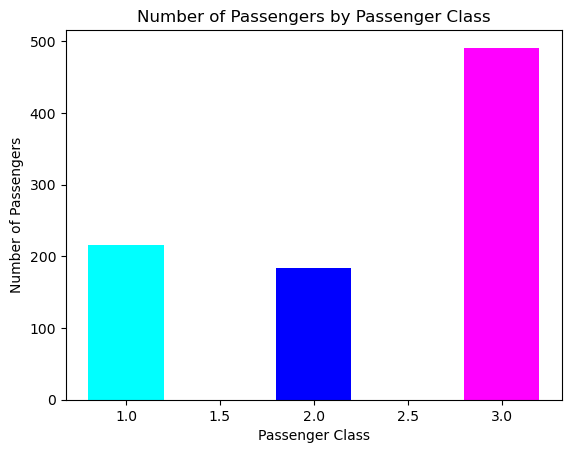

In [7]:
#رسم Bar Chart يوضّح عدد الركاب بكل فئة (pclass) — سؤال مقارنة، فهيك النوع صح.
pclass_count=titanic.groupby("pclass")["pclass"].count().sort_index()
plt.bar(pclass_count.index,pclass_count.values,color = ["cyan","blue","magenta"],width = 0.4)
plt.title("Number of Passengers by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

نحن نقارن بين عدة فئات , كم راكب بكل فئة , بالتالي نعم هذا النوع من الرسومات هو الصحيح لتمثيله

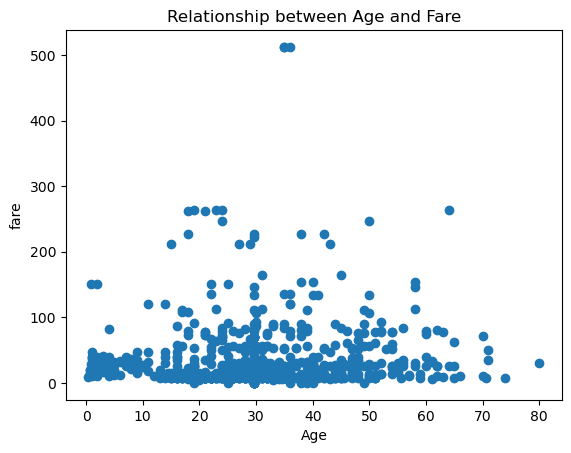

In [8]:
#ارسم Scatter Plot بين age وfare — هل في علاقة واضحة بينهم بصريًا؟
plt.scatter(titanic["age_filled"],titanic["fare"])
plt.title("Relationship between Age and Fare")
plt.xlabel("Age")
plt.ylabel("fare")
plt.show()

لا يوجد اي علاقة خطيه واضحة بين العمر و سعر التذكرة 
يوجد قيم شاذة و هي اسعار التذاكر العاليه 

Part 2 : Seaborn

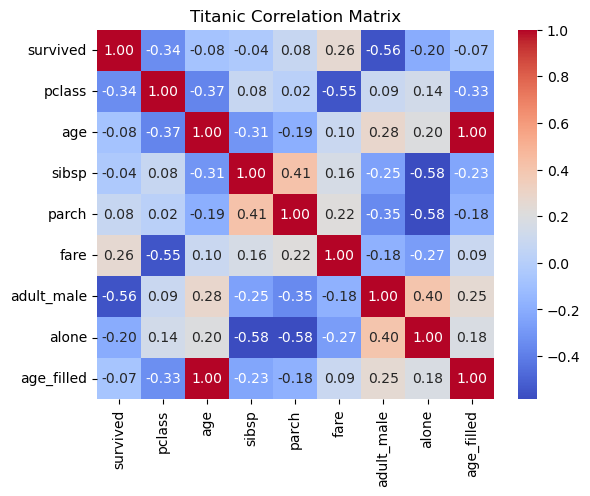

In [9]:
#احسب مصفوفة الارتباط (correlation matrix) بين الأعمدة الرقمية بالداتاسيت، وارسمها بـ sns.heatmap() — شو أقوى علاقة ارتباط لاحظتها؟
correlation_matrix = titanic.corr(numeric_only = True )
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Titanic Correlation Matrix")
plt.show()


In [ ]:
# fare and survived 0.34
#يوجد ارتباط موجب بسيط بين سعر التذكرة و فرص النجاة ,وهذه اشارة الى ان الركاب الذين دفعوا اسعار تذاكر اعلى كانت فرصهم بالنجاة اكبر 
# adult_male and survived -0.56
# ارتباط سلبي واضح و يدل على ان البالغين الذكور كانت فرص نجاتهم اقل وهذا ايضا ما لاحظناه في تحليلنا السابق حيث كانت النساء ذوات الفرص الاعلى بالنجاة 
# وهذا يدعم فرضية اعطاء الاولية للنساء فى عملي الانقاذ
# Pclass and fare -0.55
# وجد ارتباط سلبي واضح بين fare و pclass. السبب أن قيمة pclass تمثل ترتيب الفئة، حيث أن الرقم الأقل يعني فئة أعلى (First Class = 1)، بينما الرقم الأكبر يعني فئة أقل (Third Class = 3).
#لذلك أصحاب الفئات الأعلى (رقم أقل) دفعوا أسعار تذاكر أعلى، مما يفسر العلاقة العكسية بين المتغيرين
# Pclass and survived -0.34
# وجد ارتباط سلبي بسيط بين pclass و survived. وبما أن رقم الفئة الأصغر يمثل فئة اجتماعية أعلى، فإن انخفاض قيمة pclass يرتبط بارتفاع فرص النجاة
# بالتالي ركاب الدرجة الأولى والثانية كانت لديهم فرص نجاة أعلى مقارنة بركاب الدرجة الثالثة.


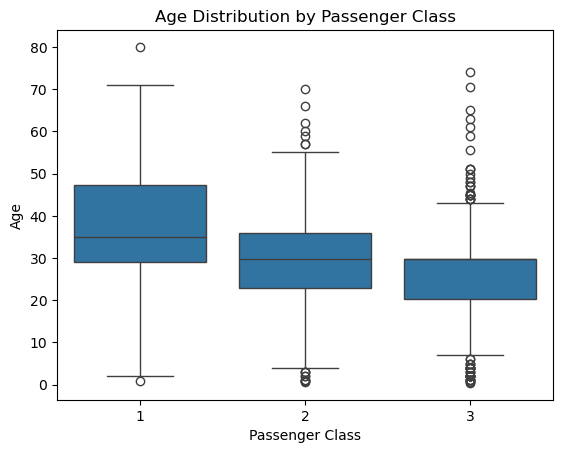

In [ ]:
#رسم boxplot لعمود age مقسوم حسب pclass — شو الفرق بمتوسط الأعمار بين الفئات الثلاث؟ (Boxplot ممتاز لمقارنة توزيعات بين فئات).
sns.boxplot(x="pclass",y="age_filled",data = titanic)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

العمر الوسيط لركاب الفئة الاولى كان تقريبا 35 عام
العمر الوسيط لركاب  الفئة الثانية تقريا 30  عام 
العمر الوسيط لركاب الفئة الثاثه كان 25 عام

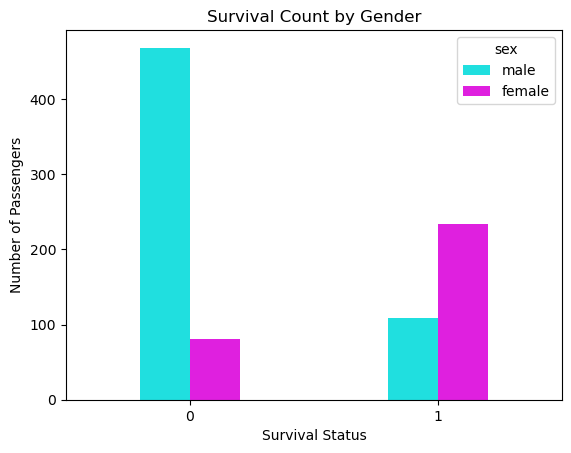

In [ ]:
#رسم countplot يوضّح عدد الناجين وغير الناجين (survived) مقسومين حسب الجنس (sex) — استخدم خاصية hue بـ Seaborn.
sns.countplot(x="survived",data=titanic,hue ="sex",palette = {"male":"cyan","female":"magenta"},width = 0.4)
plt.title("Survival Count by Gender")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

نلاحظ ان الناجين من النساء اكثر عددا من الذكور

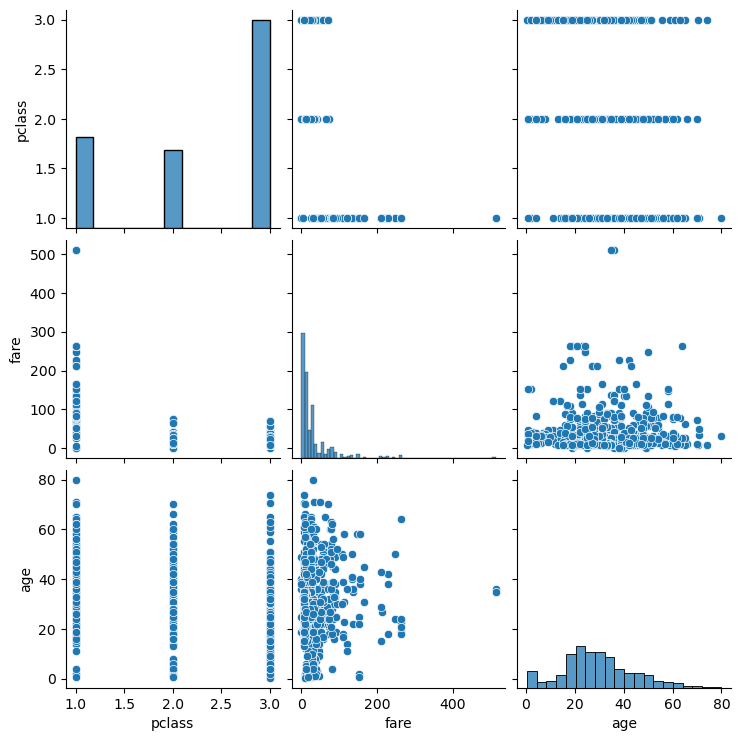

In [15]:
#ارسم pairplot لثلاث أعمدة رقمية على الأقل (مثلاً age, fare, pclass) — شو أهم ملاحظة بصرية طلعت معك؟
sns.pairplot(titanic[["pclass","fare","age"]])
plt.show()

من خلال الـ Pairplot نلاحظ أن معظم الركاب كانت أسعار تذاكرهم ضمن نطاق منخفض تقريبًا (بين 0 و100)، مع وجود عدد قليل من الركاب الذين دفعوا أسعارًا مرتفعة جدًا، مما يشير إلى وجود قيم شاذة (Outliers) في عمود fare كما يظهر وجود علاقة عكسية بين pclass و fare، حيث ترتبط الفئات الأعلى (رقم أقل) بأسعار تذاكر أعلى

In [18]:
import plotly.express as px

In [17]:
passengers_by_class =titanic.groupby("pclass").size().reset_index()
passengers_by_class.columns=["pclass","count"]
print(passengers_by_class)
passengers_by_class.dtypes

   pclass  count
0       1    216
1       2    184
2       3    491


pclass    int64
count     int64
dtype: object

In [19]:
#استخدم plotly.express (import plotly.express as px) لترسم Bar Chart تفاعلي لعدد الركاب بكل فئة (px.bar) — مرّر الماوس فوق أي عمود وشوف القيمة الدقيقة تطلع تلقائيًا.
passengers_by_class["pclass"] = passengers_by_class["pclass"].astype(str)
fig_1 = px.bar(passengers_by_class,x="pclass",y="count",title="Passengers by class",color="pclass",
            color_discrete_map={"1": "gold","2": "silver","3": "brown"})

fig_1.write_html("passengers_by_class.html")
fig_1.show()


In [20]:
#ارسم Scatter Plot تفاعلي بين age وfare، وخلي لون كل نقطة يعتمد على survived (color='survived') — جرّب تكبّر (Zoom) جزء من الرسمة بالماوس.
fig_2= px.scatter(titanic,"age","fare",color = "survived",title="Age vs Fare by Survival")

fig_2.write_html("age_vs_fare_survival.html")
fig_2.show()

In [21]:
#ارسم Histogram تفاعلي لتوزيع الأعمار، مقسوم حسب الجنس (color='sex').
fig_3 = px.histogram(titanic,x="age",title="Age Distribution by Gender",color="sex")
fig_3.show()

Part 4

In [ ]:
#"هل سعر التذكرة بيختلف كثير بين الفئات الثلاث؟" (فكّر: مقارنة توزيعات).
#استخدمت Box Plot لأنه الأنسب لمقارنة توزيعات أسعار التذاكر بين الفئات الثلاث، حيث يوضح مدى انتشار الأسعار والوسيط والقيم المتطرفة


In [22]:
titanic["pclass"] = titanic["pclass"].astype(str)

fig_4 = px.box(titanic, x="pclass", y="fare")
fig_4.show()


سعر التذكرة كان يختلف كتيرا بين الفئات الثلاثه بحيث كانت الفئة الاولى اسعارها اعلى و لديها تشتت اكبر بالاسعار , الوسيط لديها اكبر, و لديها قيم متطرفه كبيره
اما الفئة الثانيه فكانت اسعارها متوسطة و تشتتها اقل
و الفئة الثالثه كانت اسعارها منخفضه و متقاربه 


In [ ]:
#"شو نسبة الناجين والغير ناجين بشكل عام؟" (فكّر: نسب من إجمالي).
#النسبة من الاجمالي لدينا عدة خيارات اما Pie , Horizontal Bar, Virtecal Bar 
# انا هون استخدمت ال horizontal bar

In [23]:
survival = titanic["survived"].value_counts(normalize = True).reset_index()
survival.columns = ["survived", "Percentage"]
survival["Percentage"] = survival["Percentage"] * 100

survival["survival status"] = survival["survived"].map({0: "Not Survived",1: "Survived"})
fig_5 = px.bar(survival,y="survival status",x="Percentage",title ='Survival Percentage',color = "survival status",color_discrete_map={"Not Survived":"red","Survived":"cyan"})
fig_5.show()


تبين ان نسبة الناجين هي 38.38% بينما الغير ناجين كانو 61.61%

In [ ]:
#هل في علاقة بين حجم العائلة على متن السفينة (sibsp + parch) واحتمال النجاة؟" (بدك تحسب عمود جديد أول، وبعدين ترسم).
#

In [ ]:
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] #هون اوجدنا حجم العيله و انشانالها عمود منفصل
family_survival_percentage = titanic.groupby("family_size")["survived"].mean().reset_index()
family_survival_percentage["family_size"] = family_survival_percentage["family_size"].astype(str)
family_survival_percentage["survived"] = family_survival_percentage["survived"] * 100
fig_6 = px.bar(family_survival_percentage,x="family_size",y="survived",title="Survival Probability by Family Size",
                labels={"family_size": "Family Size","survived": "Survival Percentage (%)"},color = "family_size")
fig_6.show()

لم الاحظ علاقة خطية واضحة بين حجم العائلة و نسبة النجاة لكن العائلات المتوسطة الحجم كانت نسبة النجاة لديهم اعلى بينما انخفضت النسبه لدى العائلات الكبيرة و المسافرين الوحيدين

In [ ]:
#"قارن متوسط سعر التذكرة بين ميناء الصعود المختلفة (embarked)." (فكّر: مقارنة بين فئات).
# مقارنة متوسط بين فئات ف الافضل هو ال Bar

In [213]:
fare_by_class = titanic.groupby("embarked")["fare"].mean().reset_index()
print(fare_by_class)
fig_7 = px.bar(fare_by_class,x="embarked",y="fare",color="embarked",color_discrete_map={"C":"red","S":"pink","Q":"cyan"},
       title="Average Fare by Embarkation Port",labels={"embarked": "Embarkation Port","fare": "Average Fare"})
fig_7.show()

  embarked       fare
0        C  59.954144
1        Q  13.276030
2        S  27.243651


ميناء C كان متوسط السعر فيه اعلى وهو 60 ثم يليه S بسعر متوسطه 27 و بالاخير Q ب متوسط 13